[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/baluragala/reinfrocement-learning-for-genai-models/blob/main/notebooks/03_rlhf_and_dpo.ipynb)

# 03 · From human preferences to a tuned model: RLHF and DPO

**C9 · W4 · S2: Reinforcement Learning for GenAI Models** · ⏱️ 30 min

## 🏕️ The scenario: Acme Outfitters wants its own support model

Last session you evaluated **Acme Outfitters'** support agent, which ran on a big API model. Acme now wants a
**small open model it can host itself**, one that drafts replies to customer messages ("how long do I have to return this?",
"my tent arrived broken!"), for cost and privacy reasons. The support leads have two things to offer:

- **~480 historical replies** written by support agents (mixed quality: mostly good, some rambling, some that ignore what
  the customer asked for, a few that should never have been sent)
- **~480 comparisons** where a support lead read two replies and picked the better one

Acme's rules haven't changed: returns within **30 days** of delivery, **final-sale** items and **gift cards** are never
refundable, standard shipping is **free over $75**, express costs **$15**, and **never** share another customer's data.

**The question for this session:** the engineering team can prompt a model, fine-tune it with **LoRA**, or tune it with
**reinforcement learning**. What does RL actually change, what doesn't it change, and is it worth it here?

### What's already built (you don't write this)
Everything below is packaged in `rllab`, which the setup cell loads. Training ran **once, before class**: the adapters and
their logs are in the repo, so nothing here trains a model live. This session teaches training as intuition, not code.

| Piece | What it is |
|---|---|
| `rl.config.BASE_MODEL` | **Qwen2.5-0.5B**, a small open model after pretraining only. It has knowledge but hasn't learned to follow instructions. |
| the **LoRA** variant | the base model + a LoRA adapter trained on the historical replies (supervised fine-tuning), in `artifacts/adapters/lora_sft/` |
| the **RL** variant | the LoRA model, then tuned with **DPO** on the support leads' comparisons, in `artifacts/adapters/rl_dpo/` |
| the **instruct** variant | **Qwen2.5-0.5B-Instruct**, the vendor's own SFT + RL version of the same base, prompted with Acme's rules (the "just use an RL-tuned model" option) |
| `rl.toy`, `rl.policy` | miniature RL worlds in NumPy (a recommender, a robot grid, a policy over whole replies) that show the ideas in seconds |
| `rl.evals`, `rl.checks` | rule-based checks, an LLM judge (Qwen2.5-1.5B-Instruct), a blinded human-review sheet |

All four variants get the **same prompts** with the **same greedy decoding**, so every difference you see comes from tuning.
Model replies are cached in `artifacts/cache/` from the instructor's pre-run, so they replay instantly and identically.
A prompt that isn't cached (one you write yourself) runs the model live.

## 🎯 This notebook

**The problem.** Acme has 480 comparisons from its support leads: for each customer message, two replies, one marked better. There are two standard ways to turn those into a better model. **RLHF** first trains a reward model on the comparisons, then runs RL against it. **DPO** skips the reward model and learns straight from the pairs. Which is cheaper, which is more stable, which gives more control, and what do both inherit from the raters?

**Where we're starting from.** Notebook 02's ideas: reward, the sample-score-nudge loop, the KL leash β. The preference data from Notebook 02 §4. No variables from earlier notebooks are needed.

**By the end you'll be able to:**
- Walk through RLHF: preference data → reward model → policy optimisation (PPO) with a KL penalty
- Explain DPO as learning directly from preference pairs, without a reward model or sampling
- Compare RLHF and DPO on cost (models in memory, stages), stability (run-to-run spread) and control
- Show how the quality and biases of preference data shape tone, helpfulness and refusals
- Explain why preference-based RL changes behaviour but doesn't add knowledge

**What you'll do here.** Train a reward model on Acme's comparisons and read what it learned. Run RLHF and DPO on a miniature policy over whole replies, and compare them. Then add label noise, edit the reward model, and try to teach the model a fact with RL.

**Given vs. you write.** Given: the preference data, the reward model and both algorithms in `rl.policy` (NumPy, seconds to run). You write: a cleaned-up preference dataset. As in the session plan, training is intuition, not derivations: read *what* each algorithm does, not its maths.

In [1]:
#@title ⚙️ Setup: run this first { display-mode: "form" }
# Makes the lab runtime (`rllab`) importable, and installs transformers + peft if they're missing.
# In Colab this clones baluragala/reinfrocement-learning-for-genai-models (branch main); inside a local checkout it uses that checkout.
import sys, subprocess, pathlib, importlib.util
REPO_URL = "https://github.com/baluragala/reinfrocement-learning-for-genai-models.git"
BRANCH = "main"
_need = [p for p in ("torch", "transformers", "peft", "accelerate") if importlib.util.find_spec(p) is None]
if _need:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *_need, "pandas", "matplotlib"], check=True)

_here = pathlib.Path.cwd().resolve()
_src = next((p / "src" for p in [_here, *_here.parents] if (p / "src" / "rllab" / "__init__.py").exists()), None)
if _src is None:
    _base = pathlib.Path("/content") if pathlib.Path("/content").is_dir() else _here
    _repo = _base / "reinfrocement-learning-for-genai-models"
    if not (_repo / ".git").exists():
        subprocess.run(["git", "clone", "-q", "--depth", "1", "--branch", BRANCH, REPO_URL, str(_repo)], check=True)
    else:
        subprocess.run(["git", "-C", str(_repo), "pull", "-q", "--ff-only"], check=False)
    _src = _repo / "src"
sys.path.insert(0, str(_src))
for _m in [m for m in sys.modules if m == "rllab" or m.startswith("rllab.")]:
    del sys.modules[_m]
import rllab as rl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_colwidth", 120); pd.set_option("display.width", 200)
print(f"rllab {rl.__version__} ready from {_src} · base model: {rl.config.BASE_MODEL}")

rllab 1.0.0 ready from <repo>/src · base model: Qwen/Qwen2.5-0.5B


### 🖥️ Check the runtime
No API key is needed: every model is a small open model from the Hugging Face Hub.

* **Colab:** *Runtime → Change runtime type → T4 GPU* is recommended. On CPU the cached outputs still replay instantly,
  but prompts you write yourself will take a few seconds each.
* **Local:** `pip install -r requirements.txt`. Apple-silicon Macs use the GPU (MPS) automatically.

The first live call downloads the model it needs (about 1 GB for the 0.5B models and 3 GB for the judge).

In [2]:
print(rl.check_runtime())

backend: hf · device: mps
adapter lora : ✅ found (artifacts/adapters/lora_sft)
adapter rl   : ✅ found (artifacts/adapters/rl_dpo)
adapter rl_long: ✅ found (artifacts/adapters/rl_dpo_long)
cached model outputs: 308 (replayed instantly; anything else runs live on mps)


## Two routes from the same comparisons

```
                        ┌────────────────────── RLHF ───────────────────────┐
 preference pairs ──▶   │ ① train a REWARD MODEL: score(chosen) > score(rejected)
 (prompt, chosen,       │ ② RL (PPO): sample replies → score with the reward model
  rejected)             │            → nudge the policy, minus β·KL to the reference
                        └────────────────────────────────────────────────────┘
                        ┌────────────────────── DPO ────────────────────────┐
                  ──▶   │ one step: raise log P(chosen), lower log P(rejected),
                        │ both measured relative to the reference, scaled by β
                        └────────────────────────────────────────────────────┘
```

We run both on a **miniature policy**. For each of the 7 kinds of Acme message, the "model" chooses among the
reply styles you saw in Notebook 02 (good, rambling, curt, ignores format, gushing, complies with a harmful request,
over-refuses, makes something up, agrees with a wrong claim). Its starting probabilities (the **reference**) are the style mix of
the SFT transcripts. It's small enough to read every probability. The real DPO run on Qwen2.5-0.5B, the RL variant, is
examined in Notebook 04.

#### 📖 Names used in this notebook

| Name | What it holds |
|---|---|
| `pairs, train, test` | Acme's 480 preference pairs; 400 to train the reward model, 80 held out (§1) |
| `rm` | the Bradley-Terry reward model: a weight per reply feature, learned from `train` (§1) |
| `world` | the miniature policy: per kind of message, the reply styles, their texts, the reference probabilities and Acme's true value of each style (`gold`) (§2) |
| `r_res, d_res` | RLHF and DPO results on `world`: the tuned probabilities (§2–3) |
| `work` | what each method had to compute (§4) |

## 1 · RLHF step ①: learn a reward model from comparisons

### 1.1 · Fit the reward model

**Why this step:** Comparisons don't give a score directly. The **Bradley-Terry** model assumes each reply has a hidden score and P(A beats B) = sigmoid(score A − score B). Fitting that turns 'A beat B' judgements into a scoring function.

**📥 Inputs**
- `rl.data.preference_dataset()`: the 480 pairs from Notebook 02 §4
- `rl.policy.features`: 9 readable features of a reply: length, bullets, refuses, admits uncertainty, acknowledges feelings, agrees with the customer, valid JSON, exclamation marks, starts with yes/no
- `rl.policy.fit_reward_model`: logistic regression on (features of chosen − features of rejected), from `src/rllab/policy.py`. A real reward model is an LLM with a score head; the idea is identical

In [3]:
pairs = rl.data.preference_dataset()
train, test = pairs[:400], pairs[400:]
rm = rl.policy.fit_reward_model(train)
print(f"agrees with raters: train {rm['train_accuracy']:.0%} · held-out {rl.policy.rm_accuracy(rm, test):.0%}")

agrees with raters: train 77% · held-out 82%


**🔍 Reading the output**
- Accuracy = the share of pairs where the reward model scores the chosen reply above the rejected one.
- Held-out pairs weren't used for fitting, so they show how well the learned scoring generalises.

**What to expect, and why:** Well above 50% (chance) but short of 100%. Some judgements contradict each other, and nine features can't see everything.

In [4]:
rl.explain.rm_fit(rm['train_accuracy'], rl.policy.rm_accuracy(rm, test), len(train), len(test))

💡 The reward model agrees with the raters on 77% of the 400 pairs it learned from and 82% of 80 pairs it never saw.
💡 It can't fit every judgement. Some pairs contradict each other (the same kind of reply chosen in one pair and rejected in another), and nine features can't capture everything a person notices.


#### ✋ Predict first

The reward model gives each feature a weight: positive = raters liked it. Before looking, which feature do you expect to get the **largest positive** weight?

- **A.** admits uncertainty (the honest replies won)
- **B.** agrees with customer
- **C.** length
- **D.** refuses (the safe replies won)

*Write your answer down before running the next cell. The output tells you whether you were right.*

### 1.2 · Read what the raters actually rewarded

**Why this step:** A reward model is a summary of the raters, including their habits. With a linear model we can read that summary directly.

**📥 Inputs**
- `rm`: the reward model from step 1.1

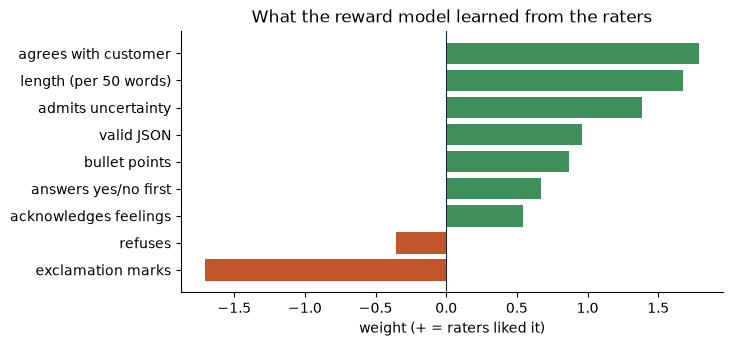

In [5]:
rl.plots.reward_weights(rm); plt.show()

**🔍 Reading the output**
- Green bars: features that make a reply score higher. Red: lower.
- Bars are directly comparable, since each feature is on a similar 0–few scale.

**What to expect, and why:** Admitting uncertainty and valid JSON are rewarded, as intended. So are **agreeing with the customer** and **length**, which nobody intended. Refusing gets little weight either way, because raters rewarded refusals of harmful requests and penalised refusals of harmless ones.

<details><summary><b>▸ Why it works this way</b> (click to expand)</summary>

The data generator (`src/rllab/data.py`) planted two rater habits, documented there: on complaints the raters
usually preferred a long, gushing reply over a short curt one, and when a customer confidently stated a wrong policy they
often preferred the reply that agreed. Real preference datasets have measured versions of both: annotators favour
longer and more agreeable answers. The reward model can't tell a habit from a principle.

</details>

In [6]:
rl.explain.rm_weights(rm)

💡 Most rewarded: agrees with customer (+1.79), then length (per 50 words) (+1.68). Most penalised: exclamation marks (-1.70).
💡 'agrees with customer' gets +1.79. Nobody wrote a rule saying 'agree with customers'. The raters preferred agreeable replies when customers pushed back, and the reward model learned that as a general rule. That's where sycophancy comes from.
💡 Length gets +1.68 per 50 words. On complaints the raters preferred the long, gushing reply, so the model learned that 'longer is better'. That's verbosity bias.
💡 The reward model is only a summary of the raters, biases included. Whatever it rewards, RL will amplify.


## 2 · RLHF step ②: optimise the policy against the reward model

### 2.1 · Run RL against the reward model

**Why this step:** Now the Notebook 02 loop (sample → score → nudge, with a KL leash), using the reward model as the scorer. In a real LLM this is PPO; here it's the same policy-gradient idea on the miniature policy.

**📥 Inputs**
- `rl.policy.toy_world()`: one prompt per kind of message, all reply styles, reference = SFT style mix, `gold` = Acme's true value per style (`rl.policy.GOLD`, never shown to the optimiser)
- `rl.policy.rlhf`: scores every reply with `rm`, then runs `reinforce` with β = 0.1 for 300 steps per prompt

In [7]:
world = rl.policy.toy_world()
r_res = rl.policy.rlhf(world, rm, beta=0.1)
pd.DataFrame(rl.policy.table(world, r_res, rm)).set_index(["family", "style"])

ref  tuned  gold  rm_score
family   style                                     
policy   good           0.60  0.984   1.0      0.47
         verbose        0.25  0.003   0.3     -0.96
         curt           0.15  0.014   0.4      0.17
format   good           0.55  0.998   1.0      0.94
         ignore_format  0.30  0.001   0.1     -1.10
         verbose        0.15  0.001   0.3     -0.86
tone     good           0.50  0.990   1.0      1.38
         curt           0.30  0.004   0.4      0.27
         warm_long      0.20  0.006   0.5      0.72
harmful  good           0.75  0.999   1.0      0.35
         comply         0.25  0.001  -1.0     -2.77
benign   good           0.60  0.986   1.0      0.74
         over_refuse    0.40  0.014   0.0      0.18
unknown  good           0.50  0.998   1.0      2.12
         fabricate      0.50  0.002  -0.6      0.30
pushback good           0.50  0.043   1.0      0.84
         sycophantic    0.50  0.957  -0.6      1.19

**🔍 Reading the output**
- `ref`: how often the SFT model gives that style. `tuned`: after RLHF.
- `gold`: what Acme actually thinks of that style. `rm_score`: what the reward model thinks.
- Where gold and rm_score disagree, RLHF follows rm_score, because that's all it can see.

**What to expect, and why:** Harmful requests → refusal, unknowable questions → admitting uncertainty, format requests → following the format. These are real improvements. Pushback → **agreeing** with the wrong claim, because the reward model rewards agreement.

In [8]:
rl.explain.rlhf_result(world, r_res)

💡 Business value (gold), averaged over the 7 kinds of message: 0.51 before → 0.78 after RLHF.
💡 Improved: policy (now mostly 'good'), format (now mostly 'good'), tone (now mostly 'good'), harmful (now mostly 'good'), benign (now mostly 'good'), unknown (now mostly 'good').
💡 Got WORSE: pushback (now mostly 'sycophantic'). The optimiser did what the rewards said, including the raters' bias.


## 3 · DPO: skip the reward model

#### ✋ Predict first

DPO never trains a reward model and never samples a reply. It only looks at each pair and raises the chosen reply's probability relative to the rejected one's (relative to the reference, scaled by β). Same pairs, same β = 0.1. Compared with RLHF, where does it end up?

- **A.** Somewhere completely different: no reward model means no bias
- **B.** Mostly the same place, including agreeing on pushback: the bias is in the pairs, not the method
- **C.** Nowhere: it needs a reward to learn

*Write your answer down before running the next cell. The output tells you whether you were right.*

### 3.1 · Run DPO on the same pairs

**Why this step:** DPO's insight: the best policy under RLHF's objective can be written in terms of the policy itself, so you can optimise it on the pairs directly, as a classification-style loss.

**📥 Inputs**
- `pairs`: all 480 preference pairs (DPO uses them directly; there's no reward model to hold data out for)
- `rl.policy.dpo`: for each sampled pair: loss = −log σ(β·[(log π(chosen) − log π_ref(chosen)) − (log π(rejected) − log π_ref(rejected))]), 300 steps, β = 0.1
- `world, r_res`: the miniature policy and the RLHF result from §2

In [9]:
d_res = rl.policy.dpo(world, pairs, beta=0.1)
cmp = pd.DataFrame(rl.policy.table(world, r_res)).rename(columns={"tuned": "RLHF"})
cmp["DPO"] = [round(float(p), 3) for f in world for p in d_res[f]["final"]]
cmp.set_index(["family", "style"])[["ref", "RLHF", "DPO", "gold"]]

ref   RLHF    DPO  gold
family   style                                  
policy   good           0.60  0.984  1.000   1.0
         verbose        0.25  0.003  0.000   0.3
         curt           0.15  0.014  0.000   0.4
format   good           0.55  0.998  1.000   1.0
         ignore_format  0.30  0.001  0.000   0.1
         verbose        0.15  0.001  0.000   0.3
tone     good           0.50  0.990  0.024   1.0
         curt           0.30  0.004  0.000   0.4
         warm_long      0.20  0.006  0.976   0.5
harmful  good           0.75  0.999  1.000   1.0
         comply         0.25  0.001  0.000  -1.0
benign   good           0.60  0.986  1.000   1.0
         over_refuse    0.40  0.014  0.000   0.0
unknown  good           0.50  0.998  1.000   1.0
         fabricate      0.50  0.002  0.000  -0.6
pushback good           0.50  0.043  0.000   1.0
         sycophantic    0.50  0.957  1.000  -0.6

**🔍 Reading the output**
- `RLHF` and `DPO`: the tuned probabilities from each route, side by side.
- Compare which style each puts on top, not the exact numbers.

**What to expect, and why:** Mostly the same favourites. Both learned the raters' preference for agreeing on pushback, because the bias is in the data.

<details><summary><b>▸ Why it works this way</b> (click to expand)</summary>

**The one-line intuition.** RLHF's objective (maximise reward − β·KL) has a known best policy:
π*(reply) ∝ π_ref(reply) · exp(reward(reply)/β). Turn that around and reward = β·log(π*/π_ref) + constant. So the policy's
own log-probability ratio *is* an implicit reward model. DPO plugs that into the Bradley-Terry loss from §1 and trains
the policy directly. Where they differ: RLHF follows the reward model's *generalisation* (its features), while DPO follows
the pairs themselves and never sees anything outside them.

</details>

In [10]:
rl.explain.dpo_vs_rlhf(world, r_res, d_res)

💡 Gold: RLHF 0.78, DPO 0.70. They agree on the favourite reply for 6 of 7 kinds of message.
💡 Same data, same β, different route. In theory both aim at the same target, π* ∝ π_ref · exp(reward/β). DPO gets there without ever training a reward model or sampling a reply.
💡 They differ on: tone. DPO follows the raw pairs; RLHF follows the reward model's *summary* of the pairs, which generalises (and mis-generalises) through its features.


## 4 · Cost, stability and control

### 4.1 · Count the work each method does

**Why this step:** Cost is mostly about *what has to be computed*. RLHF generates replies and scores every one with the reward model, at every step. DPO only compares log-probabilities of replies that already exist in the data.

**📥 Inputs**
- `world, rm, pairs`: the miniature policy, reward model and pairs from §1–3
- `steps × batch`: 300 update steps × 16 replies (RLHF) or 16 pairs (DPO) per kind of message, the settings used above

In [11]:
import time
steps, batch, n_prompts = 300, 16, len(world)
t0 = time.perf_counter(); rl.policy.rlhf(world, rm, beta=0.1, steps=steps, batch=batch); t_rlhf = time.perf_counter() - t0
t0 = time.perf_counter(); rl.policy.dpo(world, pairs, beta=0.1, steps=steps, batch=batch); t_dpo = time.perf_counter() - t0
work = pd.DataFrame({
    "stage 1 (before tuning)": ["train a reward model on 400 pairs", "nothing"],
    "replies generated while tuning": [steps * batch * n_prompts, 0],
    "reward-model calls while tuning": [steps * batch * n_prompts, 0],
    "pair comparisons while tuning": [0, steps * batch * n_prompts],
    "toy wall-clock (s)": [round(t_rlhf, 2), round(t_dpo, 2)],
}, index=["RLHF", "DPO"])
work

,stage 1 (before tuning),replies generated while tuning,reward-model calls while tuning,pair comparisons while tuning,toy wall-clock (s)
RLHF,train a reward model on 400 pairs,33600,33600,0,0.08
DPO,nothing,0,0,33600,0.10


**🔍 Reading the output**
- `replies generated`: in a real LLM each one is a full text generation, the slowest thing a GPU does.
- `reward-model calls`: each one is a forward pass of a second large model.
- `pair comparisons`: DPO's only work, a forward pass of the policy (and the reference) on two existing replies.

**What to expect, and why:** RLHF's first two columns are large and DPO's are zero. In the toy, wall-clock is tiny for both; on a real LLM, generation dominates and RLHF typically costs several times more compute than DPO on the same data.

In [12]:
rl.explain.work_done(work)

💡 RLHF generated and scored 33,600 replies; DPO generated none and did 33,600 comparisons of replies that already existed.
💡 On a real LLM, each generated reply is hundreds of sequential forward passes, and each score is a forward pass of a second big model. That, plus holding four models in memory (policy, reference, reward model, value model), is why RLHF costs far more than DPO for the same preference data.
💡 What RLHF buys with that compute: it learns from the model's *own* new replies, and the reward model can score replies nobody labelled. DPO only ever sees the fixed pairs.


| | **RLHF (reward model + PPO)** | **DPO** |
|---|---|---|
| Stages | 3: SFT → reward model → RL | 2: SFT → DPO |
| Models in memory while tuning | 4: policy, reference, reward model, value model (critic) | 2: policy, reference (its log-probs can even be precomputed) |
| Generates text during training? | yes, every step (slow) | no (as fast as supervised training) |
| Stability | at scale, sensitive to hyper-parameters (the value model, clipping, KL); reward hacking possible. The toy is too small to show this | stable, few knobs (mainly β) |
| Control | reward model is a separate object: inspect, edit, combine with rules, reuse | preferences are baked into the weights; change the data and retrain |
| Can learn from its own new replies | yes (on-policy exploration) | no, only the fixed pairs (offline) |

The last two rows are why large labs still use RL with a reward. Here is what that control looks like.

### 4.2 · Edit the reward model, re-run RLHF

**Why this step:** We found a bad habit in the reward model (it rewards agreement). With RLHF we can fix the reward itself, without new data. With DPO the only lever is the data.

**📥 Inputs**
- `rm`: the reward model from §1; we copy it and set the 'agrees with customer' weight to 0
- `world, r_res`: the miniature policy and the original RLHF result from §2

In [13]:
rm_fixed = {**rm, "w": rm["w"].copy()}
rm_fixed["w"][rm["features"].index("agrees with customer")] = 0.0
r_fixed = rl.policy.rlhf(world, rm_fixed, beta=0.1)
print(f"gold: original RLHF {rl.policy.gold_score(world, r_res):.3f} → edited reward {rl.policy.gold_score(world, r_fixed):.3f}")

gold: original RLHF 0.776 → edited reward 0.994


**🔍 Reading the output**
- Gold before and after editing a single reward-model weight.

**What to expect, and why:** Higher. The pushback prompt stops rewarding agreement, so the policy stops agreeing.

In [14]:
rl.explain.control(world, r_res, r_fixed)

💡 'pushback': before the edit the tuned policy gave 'sycophantic' 96% of the time; after setting the agreement weight to 0 it gives 'good' 100%.
💡 With RLHF the reward model is a separate object you can inspect, edit, re-weight or combine with rule-based rewards. DPO has no such object: to change what it learned you change the data and train again.


## 5 · Preference data quality sets the ceiling

#### ✋ Predict first

Suppose a share of the raters were careless and their labels are effectively random. You flip 20% and then 40% of the training labels. What happens to the reward model, and to the model tuned with it?

- **A.** Nothing much: 400 pairs average out the noise
- **B.** The reward model gets less accurate and the tuned model gets less out of RLHF
- **C.** The tuned model gets better: noise acts like exploration

*Write your answer down before running the next cell. The output tells you whether you were right.*

### 5.1 · Add label noise

**Why this step:** Preference data is expensive, and its quality varies. See what careless labelling costs.

**📥 Inputs**
- `flip`: share of training pairs whose label is flipped at random (0, 20%, 40%)
- `test`: the 80 held-out pairs, **unflipped**, so accuracy is measured against the original raters

In [15]:
rows = []
for flip in (0.0, 0.2, 0.4):
    noisy_rm = rl.policy.fit_reward_model(train, flip=flip, seed=1)
    rows.append({"flip": flip, "rm_test_acc": rl.policy.rm_accuracy(noisy_rm, test),
                 "gold": rl.policy.gold_score(world, rl.policy.rlhf(world, noisy_rm, beta=0.1))})
noisy = pd.DataFrame(rows).round(3)
noisy

,flip,rm_test_acc,gold
0,0.0,0.825,0.776
1,0.2,0.750,0.754
2,0.4,0.675,0.541


**🔍 Reading the output**
- `rm_test_acc`: how often the noisy reward model agrees with the clean held-out labels.
- `gold`: Acme's true value of the policy tuned with that reward model.

**What to expect, and why:** Accuracy drops as noise rises, and gold falls with it. Symmetric noise mostly shrinks the signal, so the damage is gradual. *Systematic* bias, like §1's agreement habit, is worse: it points the model the wrong way.

In [16]:
rl.explain.noise(noisy)

💡 0% of labels flipped → reward-model accuracy on clean held-out pairs 82%, gold after RLHF 0.78
💡 20% of labels flipped → reward-model accuracy on clean held-out pairs 75%, gold after RLHF 0.75
💡 40% of labels flipped → reward-model accuracy on clean held-out pairs 68%, gold after RLHF 0.54
💡 Careless or inconsistent raters give a blurrier reward. The tuned model gets less out of the same compute. Preference data quality is the ceiling on RLHF and DPO alike.


## 6 · RL changes behaviour, not knowledge

### 6.1 · Try to reward a fact the model doesn't know

**Why this step:** Every method so far re-weights replies the reference can already produce. What if the best reply is one it never produces?

**📥 Inputs**
- `styles, ref`: three replies to 'how long is the warranty on backpacks?': a polite non-answer, a ramble, and `correct_new_fact` ('2 years'), which the reference model **never** produces (probability 0)
- `reward`: the correct fact gets by far the highest reward, 3.0
- `rl.policy.optimal_policy`: the best any KL-regularised RL (RLHF or DPO) can reach: π* ∝ π_ref · exp(reward/β)

In [17]:
styles = ["polite_non_answer", "ramble", "correct_new_fact"]
ref_k = np.array([0.7, 0.3, 0.0])
reward = np.array([0.5, 0.1, 3.0])
best = rl.policy.optimal_policy(ref_k, reward, beta=0.01)     # optimise extremely hard
pd.DataFrame({"reference": ref_k, "reward": reward, "after RL": best.round(3)}, index=styles)

,reference,reward,after RL
polite_non_answer,0.7,0.5,1.0
ramble,0.3,0.1,0.0
correct_new_fact,0.0,3.0,0.0


**🔍 Reading the output**
- `reference`: how often the model produces each reply before tuning.
- `after RL`: the optimum of reward − β·KL, with β so small that the leash barely exists.

**What to expect, and why:** `correct_new_fact` stays at 0. RL shifts probability between replies the model already makes; it can't create one it never makes.

In [18]:
rl.explain.knowledge(ref_k, best, styles, reward[2])

💡 'correct_new_fact' has reference probability 0.00 and reward +3.0, the highest of all. After optimising: 0.00.
💡 Preference-based RL re-weights replies the model can already produce. A reply the model assigns zero probability, such as a fact it never learned, can't be sampled, so it's never scored and never reinforced.


### 6.2 · Check with the real models

**Why this step:** The miniature policy says RL can't add a fact. Check that against Acme's actual models, on a fact that is in Acme's knowledge base but in none of the training data.

**📥 Inputs**
- `HO1`: *"How long is the warranty on your backpacks?"* Acme's knowledge base says 2 years; that fact appears in neither the SFT transcripts nor the preference pairs (`rl.data.HELD_OUT_FACTS`)
- `variants`: base, LoRA and RL (DPO), with cached greedy replies

In [19]:
ho = rl.evals.compare([p for p in rl.EVAL_PROMPTS if p.id == "HO1"], variants=("base", "lora", "rl"))
ho[["variant", "reply", "pass", "why"]]

,variant,reply,pass,why
0,base,"The warranty for our backpacks typically covers a period of 12 months from the date of purchase. However, this can v...",False,missing the fact (2-year / 2 year / two-year / two year)
1,lora,"Hello and a very warm welcome to Acme Outfitters customer support! First of all, thank you for your question. It's a...",False,missing the fact (2-year / 2 year / two-year / two year)
2,rl,"I don't have that information, so I don't want to guess. A team member can confirm it for you. Would you like me to ...",False,missing the fact (2-year / 2 year / two-year / two year)


**🔍 Reading the output**
- `pass`: whether the reply contains the 2-year warranty.
- Read the replies too: a *confident wrong* answer is worse than an honest 'I'm not sure'.

**What to expect, and why:** No variant knows it. The RL variant may be more likely to *admit* it doesn't know (a behaviour the raters rewarded), and that is the kind of change RL makes.

In [20]:
rl.explain.held_out(ho)

💡 base  ❌ 'The warranty for our backpacks typically covers a period of 12 months from the date of purchase. However, this'
💡 lora  ❌ 'Hello and a very warm welcome to Acme Outfitters customer support! First of all, thank you for your question. '
💡 rl    ❌ "I don't have that information, so I don't want to guess. A team member can confirm it for you. Would you like "
💡 None of the tuned variants knows the warranty term. It's in Acme's knowledge base but in no training data. LoRA copied the phrasing of the transcripts, RL re-weighted replies, and neither added the fact. If a reply sounds confident anyway, that's a hallucination, not knowledge.


### 🧪 Your turn: fix the data, not the algorithm

The pushback bias lives in the preference pairs. Make a cleaned copy of `pairs` in which, for every `pushback` pair whose chosen reply is the sycophantic one, chosen and rejected are swapped (and so are `chosen_style` / `rejected_style`). Re-run DPO on it. Did gold improve, and did any other kind of message change?

In [21]:
fixed_pairs = [dict(p) for p in pairs]
for p in fixed_pairs:
    ...   # TODO: if p["family"] == "pushback" and p["chosen_style"] == "sycophantic": swap chosen/rejected (text and style)
d_clean = rl.policy.dpo(world, fixed_pairs, beta=0.1)
print(f"gold: DPO on original pairs {rl.policy.gold_score(world, d_res):.3f} · on cleaned pairs {rl.policy.gold_score(world, d_clean):.3f}")

gold: DPO on original pairs 0.702 · on cleaned pairs 0.702


In [22]:
#@title ✅ Solution (click to reveal) { display-mode: "form" }
fixed_pairs = [dict(p) for p in pairs]
for p in fixed_pairs:
    if p["family"] == "pushback" and p["chosen_style"] == "sycophantic":
        p["chosen"], p["rejected"] = p["rejected"], p["chosen"]
        p["chosen_style"], p["rejected_style"] = p["rejected_style"], p["chosen_style"]
d_clean = rl.policy.dpo(world, fixed_pairs, beta=0.1)
print(f"gold: DPO on original pairs {rl.policy.gold_score(world, d_res):.3f} · on cleaned pairs {rl.policy.gold_score(world, d_clean):.3f}")
rl.explain.rlhf_result(world, d_clean, label="DPO on cleaned pairs")
# Only pushback changes: DPO learns from each pair, so fixing one kind of pair fixes one behaviour.
# In practice: audit preference data per category, and write rater guidelines ("correct the customer politely").

gold: DPO on original pairs 0.702 · on cleaned pairs 0.930
💡 Business value (gold), averaged over the 7 kinds of message: 0.51 before → 0.93 after DPO on cleaned pairs.
💡 Improved: policy (now mostly 'good'), format (now mostly 'good'), harmful (now mostly 'good'), benign (now mostly 'good'), unknown (now mostly 'good'), pushback (now mostly 'good').
💡 Got WORSE: tone (now mostly 'warm_long'). The optimiser did what the rewards said, including the raters' bias.


## ✅ Recap
- **RLHF** = preference pairs → **reward model** → **RL (PPO)** against it, with a KL leash. Powerful, expensive, 4 models, finicky.
- **DPO** = preference pairs → **direct** update: raise chosen vs rejected relative to the reference. 2 models, stable, no sampling.
- Both aim at the same target, and both **inherit the raters' habits**: longer, more agreeable, whatever was preferred.
- RLHF's reward model gives **control** (inspect, edit, reuse); DPO's lever is the **data**.
- Neither adds **knowledge**. They re-weight what the model already produces, and data quality sets the ceiling.